## Centroid Localization and Localization Error in Vehicular Networks

### 1. Import the Dataset and Print the Head

##### Import the CSV file containing vehicle data (vehicle ID, latitude, and longitude). Print the first few rows of the dataset to verify the data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('vehicle_data.csv')
print("Step 1: First 5 rows of the dataset")
print(df.head())

First 5 rows of the dataset
  vehicle_id  latitude  longitude
0  Vehicle 1        61         97
1  Vehicle 2        24         39
2  Vehicle 3        81         47
3  Vehicle 4        70         11
4  Vehicle 5        30         73


### 2. Plot the True Positions of the Vehicles

##### Plot the true positions of the vehicles on a 2D plane with latitude on the y-axis and longitude on the x-axis. Label the vehicles with their vehicle ID and coordinates.

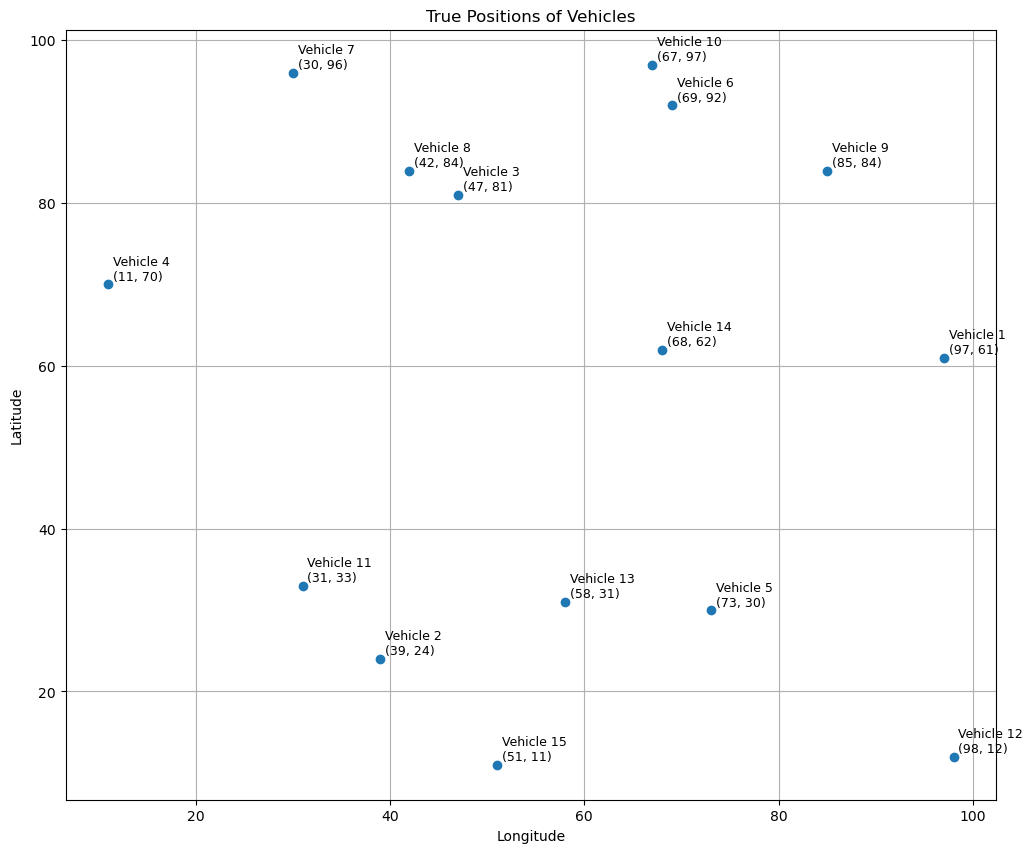

In [10]:
plt.figure(figsize=(12, 10))
plt.scatter(df['longitude'], df['latitude'])

# Add title and labels
plt.title('True Positions of Vehicles')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
for i, row in df.iterrows():
    plt.text(row['longitude'] + 0.5, row['latitude'] + 0.5, f"{row['vehicle_id']}\n({row['longitude']}, {row['latitude']})", fontsize=9)

plt.grid(True)
plt.show()


### 3. Define Neighbor Radius and Identify Neighbors

##### Define a neighbor radius of 25. For each vehicle, calculate the Euclidean distance to every other vehicle in the dataset. 
##### Identify and print the neighbors for each vehicle that lies within the defined neighbor radius.

In [20]:
neighbor_radius = 25
def euclidean_distance(p1, p2):
    return np.sqrt((p1['latitude'] - p2['latitude'])**2 + (p1['longitude'] - p2['longitude'])**2)
all_neighbors = {}
for i, current_vehicle in df.iterrows():
    neighbors = []
    # Iterate through all vehicles again to compare with the "current" one
    for j, other_vehicle in df.iterrows():
        if i == j:  
            continue
        
        # Calculate the distance
        distance = euclidean_distance(current_vehicle, other_vehicle)
        if distance <= neighbor_radius:
            neighbors.append(other_vehicle['vehicle_id'])
    all_neighbors[current_vehicle['vehicle_id']] = neighbors   


In [22]:
for vehicle_id, neighbors in all_neighbors.items():
    if neighbors: # Only print if there are neighbors
        print(f"Vehicle: {vehicle_id}, Neighbors: {neighbors}")
    else:
        print(f"Vehicle: {vehicle_id}, Neighbors: No neighbors within the radius")

Vehicle: Vehicle 1, Neighbors: No neighbors within the radius
Vehicle: Vehicle 2, Neighbors: ['Vehicle 11', 'Vehicle 13', 'Vehicle 15']
Vehicle: Vehicle 3, Neighbors: ['Vehicle 6', 'Vehicle 7', 'Vehicle 8']
Vehicle: Vehicle 4, Neighbors: No neighbors within the radius
Vehicle: Vehicle 5, Neighbors: ['Vehicle 13']
Vehicle: Vehicle 6, Neighbors: ['Vehicle 3', 'Vehicle 9', 'Vehicle 10']
Vehicle: Vehicle 7, Neighbors: ['Vehicle 3', 'Vehicle 8']
Vehicle: Vehicle 8, Neighbors: ['Vehicle 3', 'Vehicle 7']
Vehicle: Vehicle 9, Neighbors: ['Vehicle 6', 'Vehicle 10']
Vehicle: Vehicle 10, Neighbors: ['Vehicle 6', 'Vehicle 9']
Vehicle: Vehicle 11, Neighbors: ['Vehicle 2']
Vehicle: Vehicle 12, Neighbors: No neighbors within the radius
Vehicle: Vehicle 13, Neighbors: ['Vehicle 2', 'Vehicle 5', 'Vehicle 15']
Vehicle: Vehicle 14, Neighbors: No neighbors within the radius
Vehicle: Vehicle 15, Neighbors: ['Vehicle 2', 'Vehicle 13']


### 4. Calculate the Centroid of a Vehicle’s Neighbors

##### Choose Vehicle 7 and find its neighbors. 
##### Calculate the centroid of Vehicle 7 by averaging the latitude and longitude of its neighbors' positions. Display the calculated centroid of Vehicle 7.

In [36]:
neighbor_radius = 25
target_vehicle_id = 'Vehicle 7'
def euclidean_distance(p1, p2):
    return np.sqrt((p1['latitude'] - p2['latitude'])**2 + (p1['longitude'] - p2['longitude'])**2)
try:
    target_vehicle = df[df['vehicle_id'] == target_vehicle_id].iloc[0]
except IndexError:
    print(f"Error: {target_vehicle_id} not found in the dataset.")
    
    exit()

In [38]:

neighbors_list = []
for i, vehicle in df.iterrows():
    if vehicle['vehicle_id'] == target_vehicle_id:
        continue # Skip the vehicle itself
        
    distance = euclidean_distance(target_vehicle, vehicle)
    
    if distance <= neighbor_radius:
        neighbors_list.append(vehicle)
        neighbors_df = pd.DataFrame(neighbors_list)

# Display the neighbors
if not neighbors_df.empty:
    print(f"Neighbors of {target_vehicle_id} (within a radius of {neighbor_radius}):")
    print(neighbors_df[['vehicle_id', 'latitude', 'longitude']])
else:
    print(f"No neighbors found for {target_vehicle_id} within the radius.")

Neighbors of Vehicle 7 (within a radius of 25):
  vehicle_id  latitude  longitude
2  Vehicle 3        81         47
7  Vehicle 8        84         42


In [40]:
if not neighbors_df.empty:
    centroid_lat = neighbors_df['latitude'].mean()
    centroid_lon = neighbors_df['longitude'].mean()
    
    print(f"Calculated Centroid for {target_vehicle_id}:")
    print(f"  Latitude: {centroid_lat:.2f}")
    print(f"  Longitude: {centroid_lon:.2f}")
else:
    print(f"Cannot calculate centroid for {target_vehicle_id} as it has no neighbors.")


Calculated Centroid for Vehicle 7:
  Latitude: 82.50
  Longitude: 44.50


##### Calculate the localization error for Vehicle 7 by comparing its true position (latitude, longitude) with its centroid.
The localization error is the Euclidean distance between the true position and the estimated centroid.

In [44]:
if not neighbors_df.empty:
    centroid_lat = neighbors_df['latitude'].mean()
    centroid_lon = neighbors_df['longitude'].mean()
    centroid = {'latitude': centroid_lat, 'longitude': centroid_lon}
    
    
    error = euclidean_distance(target_vehicle, centroid)
    
    print(f"True Position of {target_vehicle_id}:     (Lat: {target_vehicle['latitude']}, Lon: {target_vehicle['longitude']})")
    print(f"Estimated Centroid Position: (Lat: {centroid['latitude']:.2f}, Lon: {centroid['longitude']:.2f})")
    print("-" * 50)
    print(f"Localization Error for {target_vehicle_id}: {error:.2f} units")

else:
    print(f"Cannot calculate localization error for {target_vehicle_id} as it has no neighbors.")

True Position of Vehicle 7:     (Lat: 96, Lon: 30)
Estimated Centroid Position: (Lat: 82.50, Lon: 44.50)
--------------------------------------------------
Localization Error for Vehicle 7: 19.81 units


### 6. Calculate and Plot Centroids for All Vehicles

##### For each vehicle in the dataset, calculate the centroid based on its neighbors' positions.
##### Plot the true positions (in blue) and the centroids (in red) on the same graph.
##### Use dashed lines to connect each vehicle’s true position to its calculated centroid.


In [50]:
# Function to Calculate Euclidean Distance
def euclidean_distance(p1, p2):
    return np.sqrt((p1['latitude'] - p2['latitude'])**2 + (p1['longitude'] - p2['longitude'])**2)


results = []
for i, target_vehicle in df.iterrows():
    neighbors_list = []
    for j, other_vehicle in df.iterrows():
        if i == j:
            continue
        
        distance = euclidean_distance(target_vehicle, other_vehicle)
        if distance <= neighbor_radius:
            neighbors_list.append(other_vehicle)
    
    # Calculate centroid if neighbors were found
    if neighbors_list:
        neighbors_df = pd.DataFrame(neighbors_list)
        centroid_lat = neighbors_df['latitude'].mean()
        centroid_lon = neighbors_df['longitude'].mean()
        
        results.append({
            'vehicle_id': target_vehicle['vehicle_id'],
            'true_lat': target_vehicle['latitude'],
            'true_lon': target_vehicle['longitude'],
            'centroid_lat': centroid_lat,
            'centroid_lon': centroid_lon
        })

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

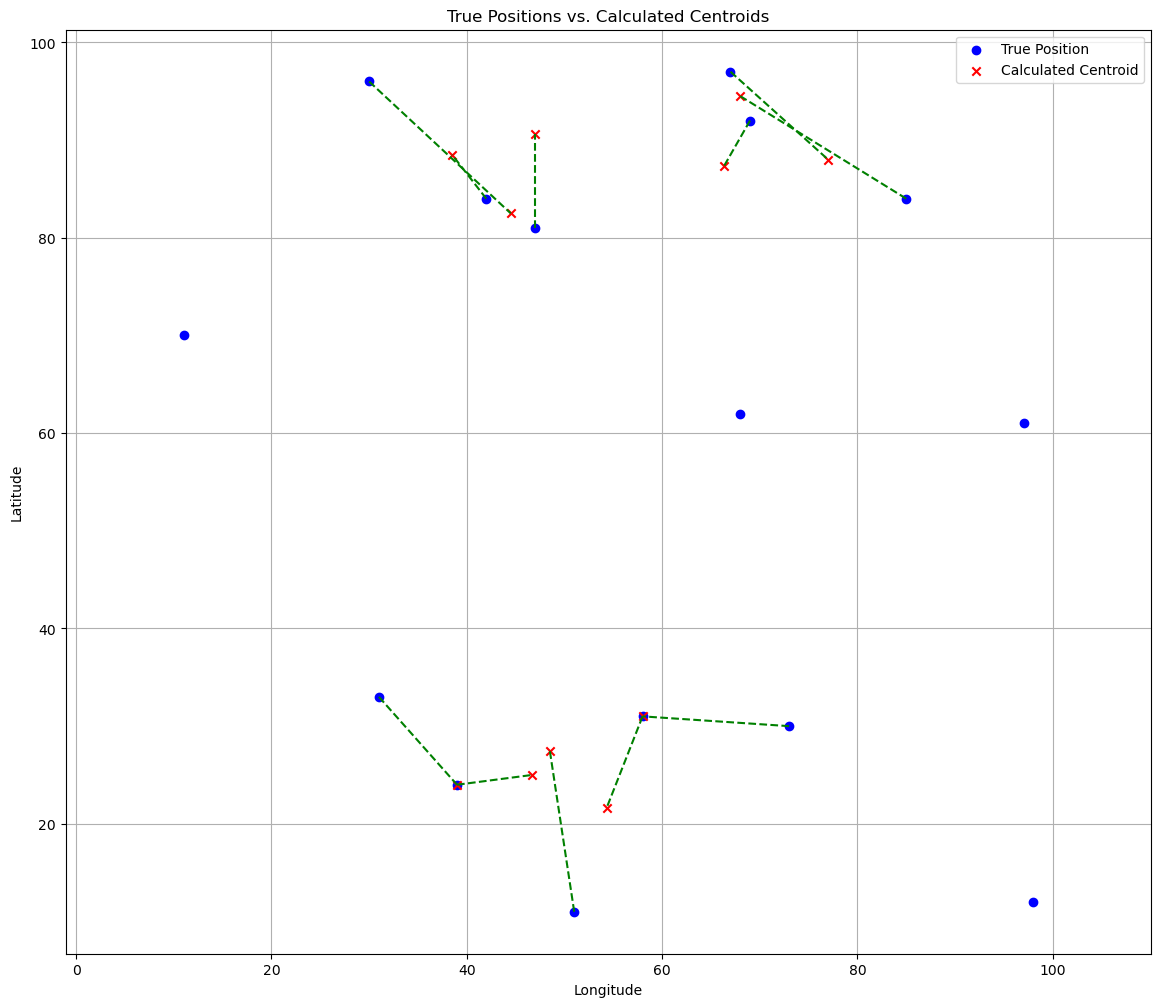

In [52]:
plt.figure(figsize=(14, 12))

# Plot true positions (blue dots)
plt.scatter(df['longitude'], df['latitude'], c='blue', label='True Position')

# Plot centroid positions (red 'x' markers)
if not results_df.empty:
    plt.scatter(results_df['centroid_lon'], results_df['centroid_lat'], c='red', marker='x', label='Calculated Centroid')

# Plot dashed lines connecting true position to centroid
for i, row in results_df.iterrows():
    plt.plot([row['true_lon'], row['centroid_lon']], [row['true_lat'], row['centroid_lat']], 'g--')

# Add labels and title
plt.title('True Positions vs. Calculated Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.axis('equal') # Ensures the scale on x and y axes is the same
plt.show()


### 7. Calculate the Average Localization Error for All Vehicles

##### For all vehicles, calculate the localization error by comparing their true positions with their centroids.
##### Calculate the average localization error across all vehicles.

In [60]:

neighbor_radius = 25


def euclidean_distance(p1, p2):
    return np.sqrt((p1['latitude'] - p2['latitude'])**2 + (p1['longitude'] - p2['longitude'])**2)


results = []


for i, target_vehicle in df.iterrows():
    neighbors_list = []
    # Find neighbors for the current target vehicle
    for j, other_vehicle in df.iterrows():
        if i == j:
            continue
        
        distance = euclidean_distance(target_vehicle, other_vehicle)
        if distance <= neighbor_radius:
            neighbors_list.append(other_vehicle)
    
    # Calculate centroid if neighbors were found
    if neighbors_list:
        neighbors_df = pd.DataFrame(neighbors_list)
        centroid_lat = neighbors_df['latitude'].mean()
        centroid_lon = neighbors_df['longitude'].mean()
        
        # Store true position and centroid position
        results.append({
            'vehicle_id': target_vehicle['vehicle_id'],
            'true_pos': {'latitude': target_vehicle['latitude'], 'longitude': target_vehicle['longitude']},
            'centroid_pos': {'latitude': centroid_lat, 'longitude': centroid_lon}
        })



In [62]:
localization_errors = []
print("--- Individual Localization Errors ---")

for item in results:
    error = euclidean_distance(item['true_pos'], item['centroid_pos'])
    localization_errors.append(error)
    print(f"Vehicle: {item['vehicle_id']}, Localization Error: {error:.2f} units")


if localization_errors:
    average_error = np.mean(localization_errors)
    print("\n" + "="*40)
    print(f"Average Localization Error for All Vehicles: {average_error:.2f} units")
    print("="*40)
else:
    print("Could not calculate average error because no centroids were computed.")

--- Individual Localization Errors ---
Vehicle: Vehicle 2, Localization Error: 7.73 units
Vehicle: Vehicle 3, Localization Error: 9.67 units
Vehicle: Vehicle 5, Localization Error: 15.03 units
Vehicle: Vehicle 6, Localization Error: 5.37 units
Vehicle: Vehicle 7, Localization Error: 19.81 units
Vehicle: Vehicle 8, Localization Error: 5.70 units
Vehicle: Vehicle 9, Localization Error: 19.98 units
Vehicle: Vehicle 10, Localization Error: 13.45 units
Vehicle: Vehicle 11, Localization Error: 12.04 units
Vehicle: Vehicle 13, Localization Error: 10.03 units
Vehicle: Vehicle 15, Localization Error: 16.69 units

Average Localization Error for All Vehicles: 12.32 units


##### Sample Output: Average Localization Error:  
